In [5]:
import numpy as np
import matplotlib.pyplot as plt
from vedo import Volume

from scipy.ndimage import map_coordinates, center_of_mass, shift


def projection_image(vol, projection="sum", axis=2):
    arr = vol.tonumpy().astype(float)

    if projection == "max":
        img = arr.max(axis=axis)
    elif projection == "sum":
        img = arr.sum(axis=axis)
    elif projection == "mean":
        img = arr.mean(axis=axis)
    else:
        raise ValueError("projection must be 'max', 'sum', or 'mean'")

    return img.astype(float)


def center_image(img):
    mask = img > 0

    if mask.sum() == 0:
        raise ValueError("Mask is empty. Try lowering the threshold.")

    cy, cx = center_of_mass(mask)

    ny, nx = img.shape
    target_cy = (ny - 1) / 2
    target_cx = (nx - 1) / 2

    centered = shift(
        img,
        shift=(target_cy - cy, target_cx - cx),
        order=1,
        mode="constant",
        cval=0
    )

    return centered


def symmetry_score_2d_masked(img, angle_deg):
    img = img.astype(float)
    mask = img > 0

    ny, nx = img.shape
    cy, cx = (np.array(img.shape) - 1) / 2

    y, x = np.meshgrid(
        np.arange(ny),
        np.arange(nx),
        indexing="ij"
    )

    X = x - cx
    Y = y - cy

    theta = np.deg2rad(angle_deg)

    # direction of candidate symmetry axis
    d = np.array([np.cos(theta), np.sin(theta)])

    # normal to that axis
    n = np.array([-d[1], d[0]])

    dot = X * n[0] + Y * n[1]

    Xr = X - 2 * dot * n[0]
    Yr = Y - 2 * dot * n[1]

    xr = Xr + cx
    yr = Yr + cy

    reflected_img = map_coordinates(
        img,
        [yr, xr],
        order=1,
        mode="constant",
        cval=0
    )

    reflected_mask = map_coordinates(
        mask.astype(float),
        [yr, xr],
        order=0,
        mode="constant",
        cval=0
    ) > 0.5

    compare_mask = mask | reflected_mask

    if compare_mask.sum() == 0:
        return np.inf

    score = np.mean(
        np.abs(img[compare_mask] - reflected_img[compare_mask])
    ) / (np.mean(np.abs(img[compare_mask])) + 1e-9)

    return score


def find_best_symmetry_axis(
    vol,
    threshold=50,
    projection="max",
    axis=2,
    step=1,
    binary=True,
):
    img = projection_image(
        vol,
        projection=projection,
        axis=axis
    )

    if binary:
        img = (img > 0).astype(float)

    img = center_image(img)

    angles = np.arange(0, 180, step)

    scores = np.array([
        symmetry_score_2d_masked(img, a)
        for a in angles
    ])

    best_angle = angles[np.argmin(scores)]
    best_score = np.min(scores)

    return {
        "image": img,
        "best_angle": best_angle,
        "best_score": best_score,
        "angles": angles,
        "scores": scores,
    }


def show_axis(img, angle_deg, title=None):
    ny, nx = img.shape
    cy, cx = np.array(img.shape) / 2

    length = max(nx, ny)

    dx = np.cos(np.deg2rad(angle_deg)) * length
    dy = np.sin(np.deg2rad(angle_deg)) * length

    plt.figure(figsize=(7, 7))
    plt.imshow(img, cmap="gray")
    plt.plot(
        [cx - dx, cx + dx],
        [cy - dy, cy + dy],
        "r-",
        linewidth=2
    )
    plt.axis("equal")
    plt.axis("off")

    if title is not None:
        plt.title(title)

    plt.show()


def plot_scores(angles, scores, title="Symmetry score by angle"):
    order = np.argsort(angles)

    plt.figure(figsize=(8, 4))
    plt.plot(angles[order], scores[order], marker="o")
    plt.xlabel("Angle degrees")
    plt.ylabel("Symmetry score")
    plt.title(title)
    plt.grid(True)
    plt.show()


# -------------------------
# Usage
# -------------------------

vol = Volume(r"C:\Users\Bruger\Desktop\DTU\fagprojekt\Ny mappe\insect-ct-reorientation\data\finished_photos\rotated\AC\tif\bcrick_1_000.tif")

result = find_best_symmetry_axis(
    vol,
    projection="max",    # "max", "sum", or "mean"
    axis=1,              # project along z onto x-y plane
    step=1,       # search every 1 degree
    binary=False          # use silhouette shape
)

print("Best angle:", result["best_angle"])
print("Best symmetry score:", result["best_score"])

show_axis(
    result["image"],
    result["best_angle"],
    title=f"Best symmetry axis: {result['best_angle']:.2f}°"
)

plot_scores(
    result["angles"],
    result["scores"],
    title="Symmetry search"
)

KeyboardInterrupt: 

In [ ]:
# ============================================================
# SEGMENTERING  (VIGTIGT: koer paa det rensede dyr, ikke raa data)
#   De roterede volumener er IKKE segmenterede: kun ~1.8% af voxels er dyret,
#   men ~19% er nonzero (baggrund/holder/stoej). Symmetri-aksen blev derfor
#   domineret af ikke-dyr-voxels (gav 165° raa mod 120° segmenteret).
#
#   multi-Otsu klasse 2 -> dilation(5) + fill_holes FOERST (saa naerliggende
#   fragmenter samles) -> derefter vaelges den stoerste intensitets-vaegtede komponent.
# ============================================================
from scipy import ndimage
from skimage.filters import threshold_multiotsu


def segment_largest_component(volume):
    thresholds = threshold_multiotsu(volume, classes=3)
    regions = np.digitize(volume, bins=thresholds)
    mask = regions == 2

    mask = ndimage.binary_dilation(mask, iterations=5)
    mask = ndimage.binary_fill_holes(mask)

    labeled, num = ndimage.label(mask)
    sizes = ndimage.sum_labels(volume, labeled, index=np.arange(1, num + 1))
    largest = int(np.argmax(sizes) + 1)
    mask = labeled == largest

    # returns mask of largest component, weighted by intensity
    return mask


def load_segmented(path):
    """Indlaes volumen, behold kun dyret (stoerste komponent), nulstil resten.
    Returnerer en vedo.Volume saa eksisterende projection_image(vol, ...) virker."""
    arr = Volume(str(path)).tonumpy().astype(float)
    mask = segment_largest_component(arr)
    clean = np.zeros_like(arr)
    clean[mask] = arr[mask]
    return Volume(clean)


In [7]:
# ============================================================
# SAMMENLIGNING af symmetri-metoder paa tvaersnittet (projektion langs Y = axis 1)
#   metrikker:  absdiff  |  iou  |  ncc (produkt-korrelation)
#   variabler:  projection in {"max","sum"} , binary in {False,True}
#   NB: koerer paa SEGMENTERET data (load_segmented) -> kun dyret.
# Koer denne for selv at inspicere; konklusionen er implementeret i naeste celle.
# ============================================================
def reflect_image(img, angle_deg):
    """Spejl billede om en akse gennem centrum ved angle_deg (samme geometri
    som symmetry_score_2d_masked, men returnerer det spejlede billede)."""
    ny, nx = img.shape
    cy, cx = (np.array(img.shape) - 1) / 2
    y, x = np.meshgrid(np.arange(ny), np.arange(nx), indexing="ij")
    X = x - cx
    Y = y - cy
    t = np.deg2rad(angle_deg)
    d = np.array([np.cos(t), np.sin(t)])
    n = np.array([-d[1], d[0]])
    dot = X * n[0] + Y * n[1]
    Xr = X - 2 * dot * n[0]
    Yr = Y - 2 * dot * n[1]
    return map_coordinates(img, [Yr + cy, Xr + cx], order=1, mode="constant", cval=0)


def symmetry_score(img, angle_deg, metric="ncc"):
    """Lavere = mere symmetrisk for alle metrikker."""
    r = reflect_image(img, angle_deg)
    mask = img > 0
    rmask = r > 0
    if metric == "absdiff":                       # normaliseret middel-abs-forskel
        cm = mask | rmask
        if cm.sum() == 0:
            return np.inf
        return np.mean(np.abs(img[cm] - r[cm])) / (np.mean(np.abs(img[cm])) + 1e-9)
    if metric == "iou":                           # 1 - silhuet-overlap
        return 1 - (mask & rmask).sum() / ((mask | rmask).sum() + 1e-9)
    if metric == "ncc":                           # 1 - normaliseret produkt-korrelation
        return 1 - np.sum(img * r) / (np.sqrt(np.sum(img ** 2) * np.sum(r ** 2)) + 1e-9)
    raise ValueError(metric)


def symmetry_curve(img, metric="ncc", step=1):
    angles = np.arange(0, 180, step)
    scores = np.array([symmetry_score(img, a, metric) for a in angles])
    return angles, scores


def cross_section(vol, projection="sum", binary=False):
    img = projection_image(vol, projection=projection, axis=1)  # langs hoved-hale (Y)
    if binary:
        img = (img > 0).astype(float)
    return center_image(img)


def n_minima(scores, rel=0.10):
    """Antal lokale minima taet paa det globale (tvetydigheds-maal)."""
    n = len(scores)
    best = scores.min()
    mins = [i for i in range(n)
            if scores[i] <= scores[(i - 1) % n] and scores[i] <= scores[(i + 1) % n]]
    return sum(1 for i in mins if scores[i] <= best * (1 + rel))


# --- koer sammenligningen paa et par volumener (segmenteret) ---
test_paths = [
    f"C:/Users/samue/Desktop/DTU/fagprojekt/data/finished_photos/rotated/BC/tif/sfaar_1_00{i}.tif" for i in range(10)
]
metrics = ["absdiff", "iou", "ncc"]
colors = {"absdiff": "red", "iou": "lime", "ncc": "cyan"}

PROJECTION = "sum"   # proev "max" for at se de falske ekstra-minima
BINARY = False

for path in test_paths:
    v = load_segmented(path)   # <-- segmenter: kun dyret tilbage
    img = cross_section(v, projection=PROJECTION, binary=BINARY)

    fig, ax = plt.subplots(1, len(metrics) + 1, figsize=(4 * (len(metrics) + 1), 4))
    ny, nx = img.shape
    cy, cx = (np.array(img.shape) - 1) / 2
    L = max(nx, ny)

    for c, m in enumerate(metrics):
        angles, scores = symmetry_curve(img, metric=m, step=5)
        best = angles[np.argmin(scores)]
        nm = n_minima(scores)
        dx = np.cos(np.deg2rad(best)) * L
        dy = np.sin(np.deg2rad(best)) * L
        ax[c].imshow(img, cmap="gray")
        ax[c].plot([cx - dx, cx + dx], [cy - dy, cy + dy], color=colors[m], lw=2)
        ax[c].set_title(f"{m}: {best} grader  (nmin={nm})", fontsize=9)
        ax[c].axis("off")

    for m in metrics:
        angles, scores = symmetry_curve(img, metric=m)
        scn = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
        ax[-1].plot(angles, scn, color=colors[m], label=m)
    ax[-1].set_title(path.split("/")[-1] + f"\nproj={PROJECTION} binary={BINARY}", fontsize=9)
    ax[-1].set_xlabel("vinkel (grader)")
    ax[-1].legend(fontsize=8)
    plt.tight_layout()
    plt.show()


NameError: name 'load_segmented' is not defined

Bedste symmetri-vinkel: 120.0 grader
Score (lavere = bedre): 0.0096


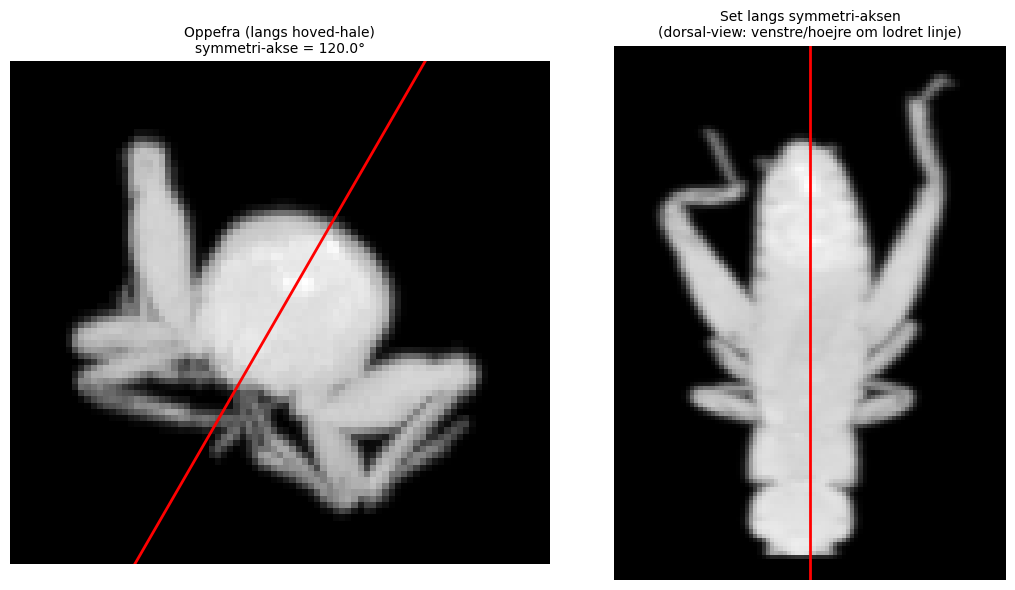

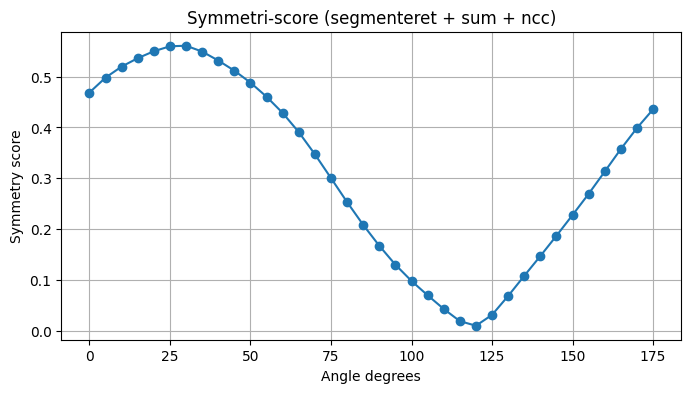

In [12]:
# ============================================================
# KONKLUSION / vinder-metode
#   SEGMENTER (load_segmented) + projection="sum" + graatone + ncc (produkt-korrelation)
#
#   - SEGMENTERING er afgoerende: raa data er ~90% ikke-dyr-voxels og trak aksen skaevt.
#   - "sum" fjerner falske lokale minima fra skarpe ben-spidser -> ET entydigt minimum.
#   - ncc = maksimer summen af de spejlede pixel-par (normaliseret), skala-invariant.
#
#   Tvaersnit = projektion langs hoved-hale-aksen (Y = axis 1).
# ============================================================
from scipy.ndimage import rotate as nd_rotate


def find_symmetry_axis(vol, projection="sum", binary=False, metric="ncc", step=1):
    img = projection_image(vol, projection=projection, axis=1)  # langs Y (hoved-hale)
    if binary:
        img = (img > 0).astype(float)
    img = center_image(img)

    angles, scores = symmetry_curve(img, metric=metric, step=step)
    best_angle = float(angles[np.argmin(scores)])

    return {
        "image": img,
        "best_angle": best_angle,
        "best_score": float(scores.min()),
        "angles": angles,
        "scores": scores,
    }


def show_axis(vol, best_angle, projection="max", downsample=2):
    """To projektioner af det segmenterede dyr:
      1) OPPEFRA  -> projektion langs hoved-hale-aksen (Y). Tvaersnit med symmetri-stregen.
      2) SET LANGS SYMMETRI-AKSEN -> projektion langs PRAECIS den fundne symmetri-akse,
         saa dyret ses venstre/hoejre-symmetrisk om en lodret hoved-hale-linje.

    Panel 2 bruger KUN den drejning der bringer best_angle i lodret (ingen fri
    re-optimering), saa de to paneler altid svarer til hinanden."""
    arr = vol.tonumpy().astype(float)
    if downsample > 1:
        arr = arr[::downsample, ::downsample, ::downsample]

    # centrer dyret om massemidtpunktet
    c = center_of_mass(arr > 0)
    arr = shift(arr, [(s - 1) / 2 - ci for s, ci in zip(arr.shape, c)],
                order=1, mode="constant", cval=0)

    mip = (lambda v, ax: v.max(axis=ax)) if projection == "max" else (lambda v, ax: v.sum(axis=ax))

    def crop_centered(img, margin=8):
        """Beskaer symmetrisk om billedets centrum, saa centrum (= massemidtpunkt)
        bliver i midten og symmetri-stregen stadig passer."""
        ys, xs = np.nonzero(img > 0)
        if len(ys) == 0:
            return img
        cy, cx = (img.shape[0] - 1) / 2, (img.shape[1] - 1) / 2
        hy = int(min(cy, np.abs(ys - cy).max() + margin))
        hx = int(min(cx, np.abs(xs - cx).max() + margin))
        return img[int(cy - hy):int(cy + hy) + 1, int(cx - hx):int(cx + hx) + 1]

    # --- panel 1: oppefra (langs Y) -> (X, Z) ---
    top = crop_centered(mip(arr, 1))

    # --- panel 2: set langs PRAECIS den fundne symmetri-akse ---
    # Drej volumenet om Y saa den fundne akse staar lodret i tvaersnittet; kun
    # de to fortegns-muligheder (best_angle-90, 90-best_angle) hoerer til aksen.
    # Vaelg den der faktisk goer tvaersnittet lodret-symmetrisk, og projicer
    # langs den nu-lodrette (dorsoventrale) retning = langs X (axis 0).
    best = {"score": np.inf}
    for alpha in (best_angle - 90.0, 90.0 - best_angle):
        rot = nd_rotate(arr, alpha, axes=(0, 2), reshape=True, order=1, mode="constant", cval=0)
        cs = center_image(mip(rot, 1))                       # roteret tvaersnit (X, Z)
        s = symmetry_score(cs, 90, metric="ncc")             # er aksen nu lodret?
        if s < best["score"]:
            best = {"score": s, "alpha": alpha,
                    "img": crop_centered(center_image(mip(rot, 0)))}  # dorsal-view langs X

    # --- plot ---
    fig, ax = plt.subplots(1, 2, figsize=(11, 6))

    ny, nx = top.shape
    cy, cx = (ny - 1) / 2, (nx - 1) / 2
    L = max(nx, ny)
    dx = np.cos(np.deg2rad(best_angle)) * L
    dy = np.sin(np.deg2rad(best_angle)) * L
    ax[0].imshow(top, cmap="gray")
    ax[0].plot([cx - dx, cx + dx], [cy - dy, cy + dy], "r-", lw=2)
    ax[0].set_xlim(-0.5, nx - 0.5)
    ax[0].set_ylim(ny - 0.5, -0.5)
    ax[0].set_title(f"Oppefra (langs hoved-hale)\nsymmetri-akse = {best_angle:.1f}°", fontsize=10)
    ax[0].axis("off")

    d = best["img"]
    ax[1].imshow(d, cmap="gray")
    ax[1].axvline((d.shape[1] - 1) / 2, color="r", lw=2)
    ax[1].set_title("Set langs symmetri-aksen\n(dorsal-view: venstre/hoejre om lodret linje)", fontsize=10)
    ax[1].axis("off")

    plt.tight_layout()
    plt.show()


# -------------------------
# Usage
# -------------------------
vol = load_segmented(
    r"C:\Users\Bruger\Desktop\DTU\fagprojekt\Ny mappe\insect-ct-reorientation\data\finished_photos\rotated\AC\tif\bcrick_1_000.tif"
)

res = find_symmetry_axis(vol, projection="sum", binary=False, metric="ncc", step=5)

print("Bedste symmetri-vinkel:", round(res["best_angle"], 2), "grader")
print("Score (lavere = bedre):", round(res["best_score"], 4))

show_axis(vol, res["best_angle"], projection="max", downsample=2)

plot_scores(
    res["angles"],
    res["scores"],
    title="Symmetri-score (segmenteret + sum + ncc)",
)


---
# Ny del: 3D-spejlings-symmetri (mere robust)

Den gamle metode scorer symmetri på **2D-tværsnittet** (sum-projektion langs hoved-hale-aksen). For nogle dyr (fx `bcrick_1_003`, `bcrick_1_007`) er det tværsnit næsten fladt/tvetydigt, så aksen bliver ustabil.

**3D-spejling** scorer i stedet hele det segmenterede volumen: vi spejler det skive-for-skive i kandidat-planet (som indeholder hoved-hale-aksen Y) og måler `ncc` mellem volumen og dets spejling. Det bruger hele kroppens 3D-struktur og giver et skarpere, entydigt minimum.

Test (kontrast, højere = mere entydigt):

| | 000 (god) | 003 | 007 |
|---|---|---|---|
| 2D tværsnit | 1.7 | 1.2 | 1.1 |
| **3D-spejling** | **3.2** | 1.7 | **2.1** |

Derudover beregnes en **konfidens** (= kontrast). Lav konfidens flagger automatisk krumme/vredne dyr (som 003), hvor der reelt ikke findes ét plant symmetriplan.

> De gamle celler ovenfor er uændret — denne del er et selvstændigt alternativ.

In [28]:
# ============================================================
# 3D-spejlings-symmetri (genbruger reflect_image, center_image, load_segmented)
# ============================================================
from scipy.ndimage import binary_erosion


def reflect_volume_plane(arr, angle_deg):
    """Spejl hver Y-skives (X,Z) om linjen ved angle_deg -> 3D-spejling i planet
    der indeholder hoved-hale-aksen (Y bevares)."""
    out = np.zeros_like(arr)
    for j in range(arr.shape[1]):
        out[:, j, :] = reflect_image(arr[:, j, :], angle_deg)
    return out


def symmetry_score_3d(arr, angle_deg):
    """1 - ncc mellem volumenet og dets spejling i planet. Lavere = mere symmetrisk."""
    r = reflect_volume_plane(arr, angle_deg)
    num = float(np.sum(arr * r))
    den = float(np.sqrt(np.sum(arr ** 2) * np.sum(r ** 2))) + 1e-9
    return 1.0 - num / den


def find_symmetry_axis_3d(vol, step=2, downsample=2, erode_legs=0):
    """Find symmetri-planet via 3D-spejling af hele dyret.
      step       : vinkel-oploesning (grader)
      downsample : hastighed (2 = hver 2. voxel)
      erode_legs : >0 -> erodér masken og fjern tynde ben (krop-only); 0 = fra
    Returnerer ogsaa 'confidence' = (median - min)/std af score-kurven
    (hoej = entydigt symmetriplan; lav = krum/vredet dyr uden plant symmetriplan)."""
    arr = vol.tonumpy().astype(float)
    if downsample > 1:
        arr = arr[::downsample, ::downsample, ::downsample]

    # centrer dyret om massemidtpunktet, saa planet gaar gennem centrum
    c = center_of_mass(arr > 0)
    arr = shift(arr, [(s - 1) / 2 - ci for s, ci in zip(arr.shape, c)],
                order=1, mode="constant", cval=0)

    if erode_legs > 0:
        arr = arr * binary_erosion(arr > 0, iterations=erode_legs)

    angles = np.arange(0, 180, step)
    scores = np.array([symmetry_score_3d(arr, a) for a in angles])
    return {
        "best_angle": float(angles[np.argmin(scores)]),
        "best_score": float(scores.min()),
        "confidence": float((np.median(scores) - scores.min()) / (scores.std() + 1e-9)),
        "angles": angles,
        "scores": scores,
    }


3D symmetri-vinkel: 122.0 grader
Konfidens (kontrast): 3.36  ->  OK


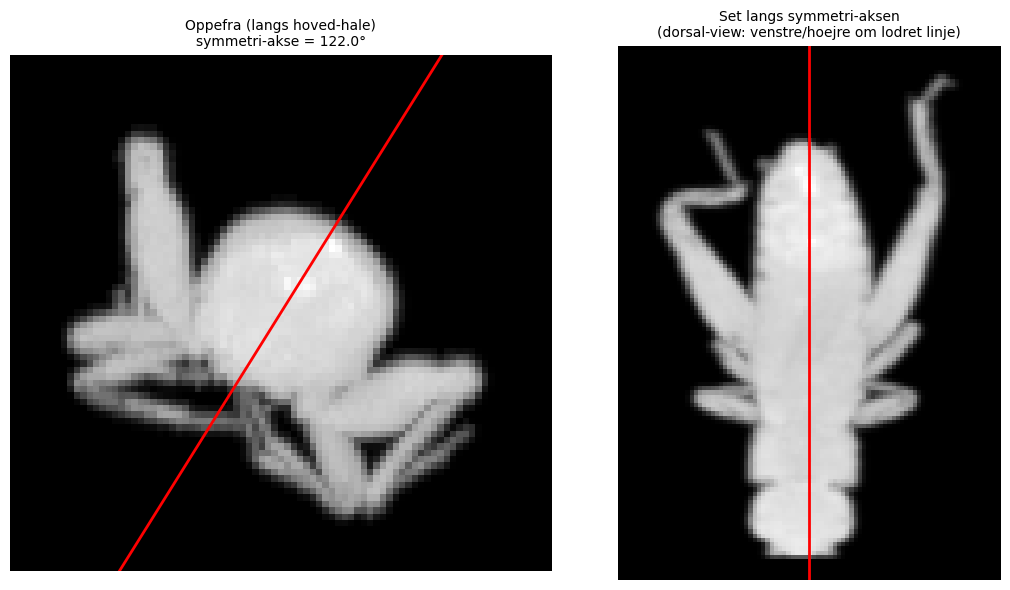

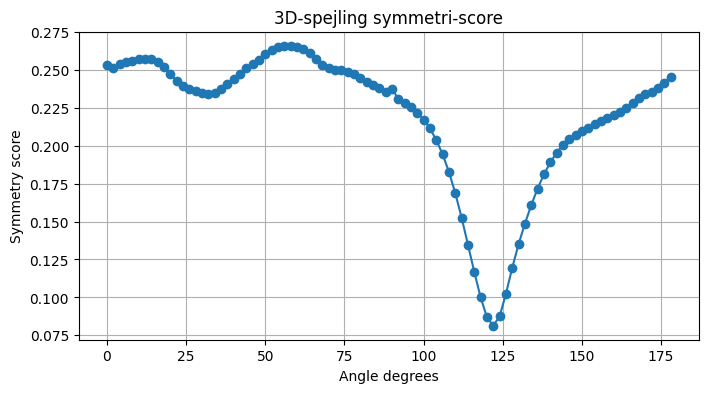

In [30]:
# -------------------------
# Brug: 3D-spejling + konfidens-flag + visualisering
# -------------------------
CONF_THRESHOLD = 2.0   # under dette flagges dyret til manuelt tjek (typisk krum/vredet)

vol = load_segmented(
    r"C:/Users/samue/Desktop/DTU/fagprojekt/data/finished_photos/rotated/AC/tif/bcrick_1_000.tif"
)

res3d = find_symmetry_axis_3d(vol, step=2, downsample=2, erode_legs=0)

flag = "OK" if res3d["confidence"] >= CONF_THRESHOLD else "LAV KONFIDENS -> tjek manuelt"
print(f"3D symmetri-vinkel: {res3d['best_angle']:.1f} grader")
print(f"Konfidens (kontrast): {res3d['confidence']:.2f}  ->  {flag}")

# genbruger den eksisterende show_axis (oppefra + set langs symmetri-aksen)
show_axis(vol, res3d["best_angle"], projection="max", downsample=2)

plot_scores(res3d["angles"], res3d["scores"], title="3D-spejling symmetri-score")


In [ ]:
# -------------------------
# Oversigt: 3D-vinkel + konfidens-flag for alle AC-volumener
# -------------------------
import glob

paths = sorted(glob.glob(
    r"C:/Users/samue/Desktop/DTU/fagprojekt/data/finished_photos/rotated/AC/tif/*.tif"
))

print(f"{'fil':20s} {'vinkel':>7s} {'konf':>6s}  flag")
for p in paths:
    r = find_symmetry_axis_3d(load_segmented(p), step=4, downsample=3)  # grovere = hurtigere
    flag = "ok" if r["confidence"] >= CONF_THRESHOLD else "FLAG (tjek manuelt)"
    name = p.replace("\\", "/").split("/")[-1]
    print(f"{name:20s} {r['best_angle']:7.1f} {r['confidence']:6.2f}  {flag}")
